# Occasion Distribution Analysis (combined_df, 23,393 rows)

Before adding an occasion-classification head, this notebook checks whether the `usage` column has enough signal to be useful, and where the class imbalance lands. **Conclusion up front:** the data supports a 3-class occasion head (Casual / Sports / Formal), but the imbalance and per-subcategory skew change how we'd evaluate it.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/combined_df.csv")
print(f"Total rows: {len(df):,}")
df[["id", "subCategory", "articleType", "usage", "baseColour"]].head()

Total rows: 23,393


,id,subCategory,articleType,usage,baseColour
0,15970,Tops,Shirts,Casual,Navy Blue
1,39386,Bottomwear,Jeans,Casual,Blue
2,21379,Bottomwear,Track Pants,Casual,Black
3,53759,Tops,Tshirts,Casual,Grey
4,1855,Tops,Tshirts,Casual,Grey


## 1. Overall occasion distribution

`usage` is the only occasion-like column in the dataset. Five values, but two are essentially absent:

        count    pct
usage               
Casual  18036  77.10
Sports   3558  15.21
Formal   1774   7.58
Party      24   0.10
Travel      1   0.00


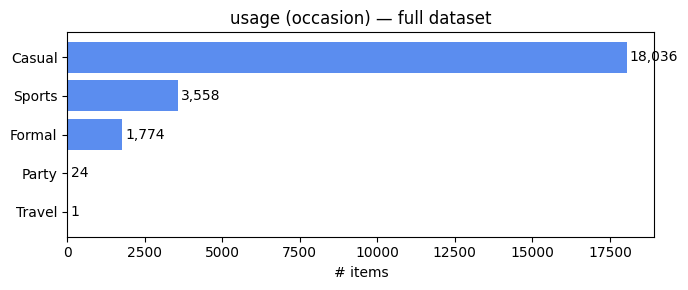

In [2]:
counts = df["usage"].value_counts(dropna=False)
pct    = (counts / len(df) * 100).round(2)
summary = pd.DataFrame({"count": counts, "pct": pct})
print(summary)

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(counts.index[::-1], counts.values[::-1], color="#5b8def")
ax.set_xlabel("# items"); ax.set_title("usage (occasion) — full dataset")
for i, v in enumerate(counts.values[::-1]):
    ax.text(v + 100, i, f"{v:,}", va="center")
plt.tight_layout(); plt.show()

**Decision:** drop *Party* (24 rows) and *Travel* (1 row). Both are too small to learn or evaluate meaningfully. Working set becomes 23,368 rows across **3 classes: Casual / Sports / Formal**.

## 2. Class imbalance

Across the 3 useful classes, the ratio is roughly **10 : 2 : 1** (Casual : Sports : Formal). A model that always predicts "Casual" gets ~77% accuracy. This means:

- Use **class-weighted CrossEntropyLoss** (or oversampling), not flat training.
- Track **macro-F1** and **per-class recall**, not just overall accuracy.
- Confusion matrix is the most honest metric here.

In [3]:
VALID_USAGES = ["Casual", "Sports", "Formal"]
df3 = df[df["usage"].isin(VALID_USAGES)].copy()
print(f"Rows after dropping Party/Travel: {len(df3):,}")

# Inverse-frequency weights for use as CrossEntropyLoss(weight=...)
freq = df3["usage"].value_counts()
weights = (len(df3) / (len(VALID_USAGES) * freq)).round(3)
print("\nSuggested class weights for CrossEntropyLoss:")
print(weights)

Rows after dropping Party/Travel: 23,368

Suggested class weights for CrossEntropyLoss:
usage
Casual    0.432
Sports    2.189
Formal    4.391
Name: count, dtype: float64


## 3. Where the occasion signal actually lives

Most subCategories are dominated by Casual. Sports/Formal signal is concentrated in **Shoes**, **Bottomwear**, and **Outerwear**:

In [4]:
ct  = pd.crosstab(df3["subCategory"], df3["usage"])
pct = pd.crosstab(df3["subCategory"], df3["usage"], normalize="index") * 100

print("Counts:\n", ct, "\n")
print("Row-normalized (%):\n", pct.round(1))

Counts:
 usage        Casual  Formal  Sports
subCategory                        
Bottomwear     1825     249     463
Dress           459       2       0
Outerwear       195       7      76
Shoes          4664     645    2010
Tops          10893     871    1009 

Row-normalized (%):
 usage        Casual  Formal  Sports
subCategory                        
Bottomwear     71.9     9.8    18.2
Dress          99.6     0.4     0.0
Outerwear      70.1     2.5    27.3
Shoes          63.7     8.8    27.5
Tops           85.3     6.8     7.9


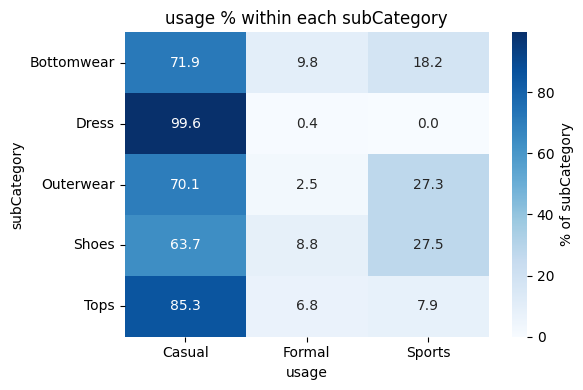

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(pct.round(1), annot=True, fmt=".1f", cmap="Blues",
            cbar_kws={"label": "% of subCategory"}, ax=ax)
ax.set_title("usage % within each subCategory")
plt.tight_layout(); plt.show()

Reading the table:

- **Dress** is ~96% Casual → effectively no occasion signal to learn.
- **Tops** is 85% Casual → narrow signal for Sports/Formal.
- **Bottomwear**, **Outerwear**, **Shoes** are where Sports and Formal have real volume — these are the rows the occasion head will actually learn from.

## 4. Why a visual model can learn this

`articleType` (e.g. "Formal Shoes" vs "Sports Shoes" vs "Casual Shoes") is *almost deterministic* of `usage`. We're not training on `articleType` — but the visual features that distinguish dress shoes from sneakers from running shoes are exactly what a fine-tuned CNN learns. So the occasion head should pick up genuine signal from the pixels.

In [6]:
top_types = df3["articleType"].value_counts().head(20).index
by_type   = pd.crosstab(df3.loc[df3["articleType"].isin(top_types), "articleType"],
                        df3.loc[df3["articleType"].isin(top_types), "usage"])
by_type   = by_type.loc[top_types]
print(by_type)

usage         Casual  Formal  Sports
articleType                         
Tshirts         6112       2     955
Shirts          2333     866       0
Casual Shoes    2820      14      12
Sports Shoes      40       0    1996
Tops            1700       3      12
Heels           1288      23       0
Formal Shoes      30     607       0
Jeans            609       0       0
Shorts           355       0     190
Trousers         289     236       0
Flats            484       1       2
Dresses          443       2       0
Track Pants      115       0     189
Sweatshirts      251       0      34
Sweaters         269       0       8
Jackets          180       0      76
Tunics           202       0       0
Capris           125       0      48
Leggings         146       0       1
Skirts            99      13       5


## 5. "Occasion" ≠ "style genre"

The project plan talks about style genres like **Punk**, **Minimalist**, **Business Casual**, **Athletic**. This dataset doesn't have those labels — only Casual / Sports / Formal. So:

- An occasion classifier can predict **Casual / Sports / Formal** from the image.
- **Style genres** still need to come from rules over `(category, color, articleType, occasion)` per the team plan — e.g. "black leather outerwear + boots → Punk". The model can't learn Punk from this data because there are no Punk labels.

Don't conflate the two when presenting results.

## 6. Decisions

If/when we add an occasion head:

1. **3 classes: Casual / Sports / Formal.** Drop Party + Travel (25 rows total).
2. **Class-weighted CrossEntropyLoss** using inverse-frequency weights (computed in §2).
3. **Evaluate with macro-F1 and confusion matrix**, not accuracy alone.
4. **Don't market it as "style/genre".** Style genres are produced by the rule-based outfit engine, not this head.